# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

# Global Mobile Operating System Adoption: A Spatial and Time-Series Analysis

## Dataset Description

The dataset used in this analysis was obtained from StatCounter Global Stats and contains monthly mobile operating system market share data from June 2015 through June 2026.

The dataset includes seven geographic regions:
- Africa
- Asia
- Europe
- North America
- Oceania
- South America
- Worldwide

The features used in this analysis include:
- Date
- Region
- Android market share
- iOS market share
- Other operating systems

This dataset was selected because it contains both time-series data and spatial data, allowing the analysis of how mobile operating system adoption changes over time and throughout different regions of the world. The results may provide insight into global mobile software development trends and the demand for Android and iOS development.

## Data Preparation

In [4]:
import pandas as pd
import plotly.express as px

mobile_df = pd.read_csv("mobile_os_market_share_2015_2026.csv")

mobile_df["Date"] = pd.to_datetime(mobile_df["Date"])
mobile_df["Year"] = mobile_df["Date"].dt.year

In [5]:
yearly_region = (
    mobile_df
    .groupby(["Year", "Region"])[["Android", "iOS", "Other"]]
    .mean()
    .reset_index()
)

yearly_region.head()

,Year,Region,Android,iOS,Other
0,2015,Africa,64.544286,3.551429,31.904286
1,2015,Asia,69.612857,11.348571,19.038571
2,2015,Europe,64.008571,28.102857,7.888571
3,2015,North America,50.208571,46.251429,3.540000
4,2015,Oceania,41.698571,54.844286,3.457143


In [13]:
region_code_map = {
    "Africa": "Africa",
    "Asia": "Asia",
    "Europe": "Europe",
    "North America": "North America",
    "Oceania": "Oceania",
    "South America": "South America"
}

map_df = yearly_region[
    yearly_region["Region"] != "Worldwide"
].copy()

map_df["Dominant_OS"] = map_df.apply(
    lambda row: "Android" if row["Android"] > row["iOS"] else "iOS",
    axis=1
)

map_df["Dominance_Gap"] = abs(
    map_df["Android"] - map_df["iOS"]
)

## Visualization 1: Worldwide Mobile Operating System Trends

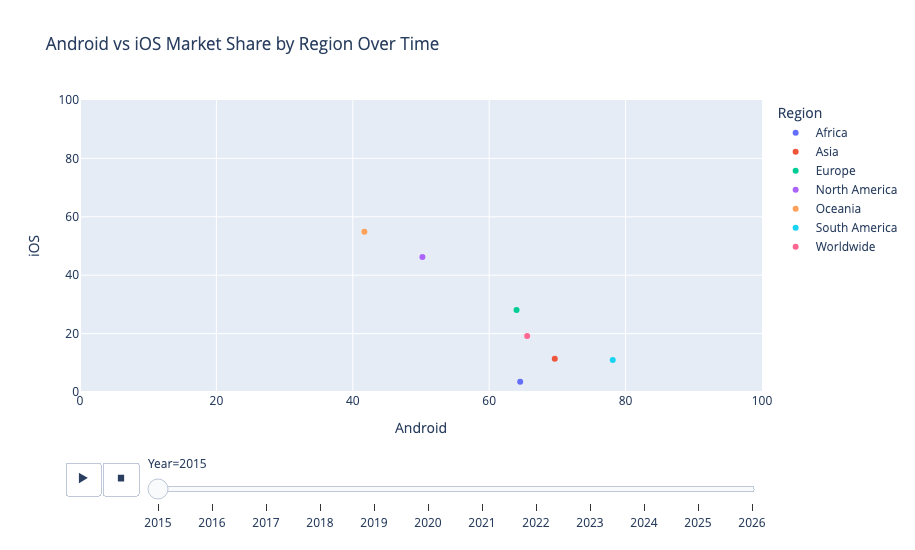

In [17]:
fig = px.scatter(
    yearly_region,
    x="Android",
    y="iOS",
    color="Region",
    hover_name="Region",
    animation_frame="Year",
    title="Android vs iOS Market Share by Region Over Time",
    range_x=[0,100],
    range_y=[0,100]
)

fig.update_layout(height=550)

fig.show()

### Interpretation

The animated scatter plot demonstrates how Android and iOS market share changed across different regions between 2015 and 2026. Regions with higher Android adoption appear farther to the right on the graph, while regions with higher iOS adoption appear higher on the graph.

Throughout the study period, Africa, Asia, and South America remained strongly associated with Android adoption, while North America and Oceania consistently exhibited higher iOS market share. Europe generally remained between the two extremes. The movement of the regions over time indicates that although market shares have changed slightly, the overall geographic differences between Android and iOS adoption have remained relatively stable.

From a software development perspective, these results suggest that Android development may reach larger global audiences, while iOS development continues to be especially important in North America and several developed regions.

## Visualization 2: Regional Android Market Share

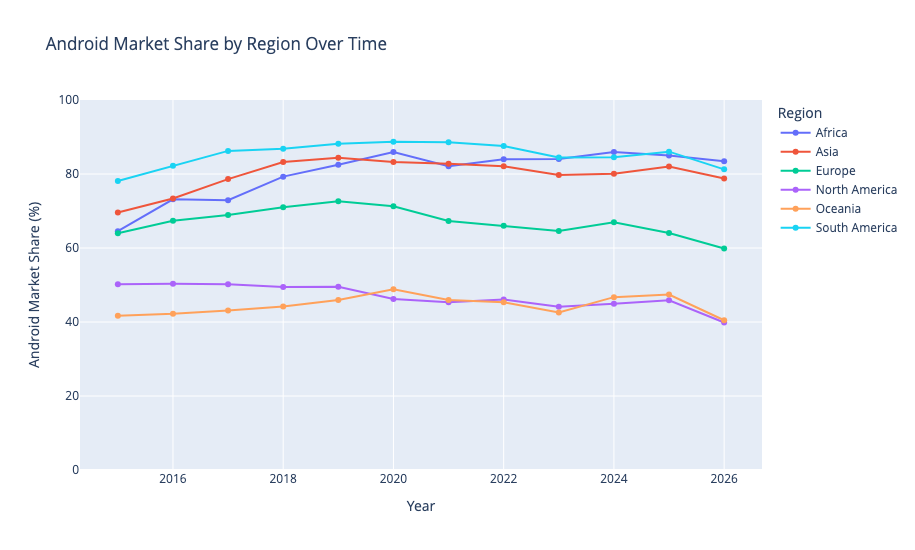

In [18]:
fig = px.line(
    yearly_region[yearly_region["Region"] != "Worldwide"],
    x="Year",
    y="Android",
    color="Region",
    markers=True,
    title="Android Market Share by Region Over Time",
    labels={
        "Year": "Year",
        "Android": "Android Market Share (%)",
        "Region": "Region"
    }
)

fig.update_layout(
    height=550,
    yaxis_range=[0, 100]
)

fig.show()

### Interpretation

This line chart shows how Android market share changed across regions from 2015 through 2026. Android remained strongest in South America, Africa, and Asia, while North America and Oceania consistently had lower Android adoption.

The regional lines show that Android usage does not change equally throughout space. Some regions remain heavily Android-dominant over time, while North America and Oceania remain more balanced between Android and iOS. For software developers, this suggests that Android-focused development may reach larger audiences in regions such as South America, Africa, and Asia.

## Visualization 3: Regional iOS Adoption Over Time

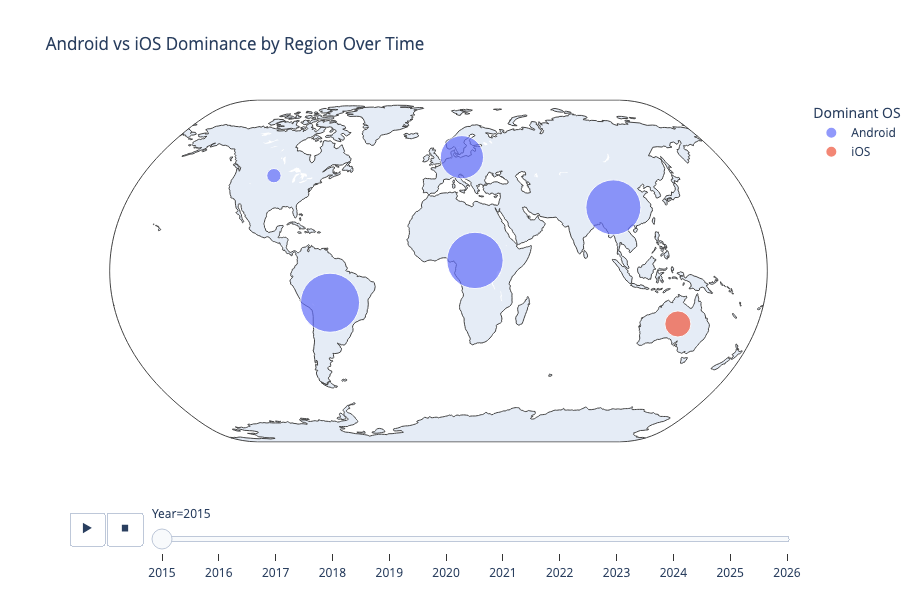

In [19]:
region_coords = pd.DataFrame({
    "Region": [
        "Africa",
        "Asia",
        "Europe",
        "North America",
        "Oceania",
        "South America"
    ],
    "lat": [5, 30, 54, 45, -25, -15],
    "lon": [20, 100, 15, -100, 135, -60]
})

map_df = yearly_region[
    yearly_region["Region"] != "Worldwide"
].merge(
    region_coords,
    on="Region"
)

map_df["Dominant_OS"] = map_df.apply(
    lambda row: "Android" if row["Android"] > row["iOS"] else "iOS",
    axis=1
)

map_df["Dominance_Gap"] = abs(
    map_df["Android"] - map_df["iOS"]
)

fig = px.scatter_geo(
    map_df,
    lat="lat",
    lon="lon",
    color="Dominant_OS",
    size="Dominance_Gap",
    hover_name="Region",
    animation_frame="Year",
    projection="natural earth",
    title="Android vs iOS Dominance by Region Over Time",
    labels={
        "Dominant_OS": "Dominant OS",
        "Dominance_Gap": "Market Share Difference"
    },
    size_max=45
)

fig.update_layout(height=600)

fig.show()

### Interpretation

The animated map illustrates how Android and iOS market dominance changed across different regions between 2015 and 2026. Regions where Android maintained a higher market share remained predominantly located in Asia, Africa, and South America, while North America and Oceania consistently showed stronger iOS adoption.

Although market shares shifted slightly over time, the geographic distribution of mobile operating system dominance remained relatively stable. Android continued to dominate many developing and emerging markets, while iOS maintained stronger positions in wealthier regions such as North America and Oceania.

From a software development perspective, these results suggest that Android development may reach larger global audiences, while iOS development remains particularly important for applications targeting North American and Oceanian users. The visualization demonstrates how mobile platform preferences vary throughout both time and geographic space.

# Conclusion

This analysis examined mobile operating system market share across multiple regions between 2015 and 2026 using time-series and spatial visualizations. The results showed that Android consistently maintained higher market share in regions such as Asia, Africa, and South America, while iOS remained strongest in North America and Oceania.

The visualizations demonstrated that geographic location plays a significant role in mobile operating system adoption. Although market shares changed slightly over time, the overall regional patterns remained relatively stable throughout the study period. Android continued to dominate many global markets, while iOS maintained strong positions in several developed regions.

From a software development perspective, these findings are particularly relevant because platform popularity varies depending on the target audience and geographic location. Developers building applications for global markets may prioritize Android development due to its larger worldwide market share, while iOS development remains especially important when targeting North American and Oceanian users.

Overall, the combination of animated scatter plots, regional trend analysis, and geographic visualizations provided insight into how mobile operating system usage changes over both time and space. These visualizations demonstrate the importance of considering geographic trends when making software development and platform support decisions.

I was hoping to find a trend in this information that showed one operating system eventually outperforming the other over time. A lot of this was driven by my own interests because I would honestly rather develop applications for iOS than Android. However, the data seems to point toward Android being the better platform to learn due to its much larger market share across most regions of the world.

While iOS remains very strong in North America and Oceania, Android dominates many other regions. From a software development perspective, this suggests that learning Android development may provide access to a larger global audience, even if my personal preference is to develop for iOS.